In [16]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DIR = "/content/drive/MyDrive/MLOPS-40"
os.chdir(DIR)

df = pd.read_csv("power_tetouan_city_clean.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,hour,day,month,year
0,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0.0,1.0,1.0,2017.0
1,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0.0,1.0,1.0,2017.0
2,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0.0,1.0,1.0,2017.0
3,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0.0,1.0,1.0,2017.0
4,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048,0.0,1.0,1.0,2017.0


In [3]:
# UTILIDADES: PSI & GRAFICOS

def calculate_psi(expected, actual, buckets=10):
    """Calcula PSI para detectar drift en distribuciones."""
    expected_perc = np.histogram(expected, bins=buckets)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=buckets)[0] / len(actual)
    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi


def plot_feature_shift(X_val, X_mon):
    """Grafica la distribución de features entre validación y monitoreo."""
    features = X_val.columns
    plt.figure(figsize=(14, 4 * len(features)))

    for i, feat in enumerate(features):
        plt.subplot(len(features), 1, i + 1)
        sns.kdeplot(X_val[feat], label="Validación", fill=True)
        sns.kdeplot(X_mon[feat], label="Monitoreo", fill=True)
        plt.title(f"Distribución del Feature: {feat}")
        plt.legend()

    plt.tight_layout()
    plt.show()


In [4]:
# GENERACIÓN DE DATASET BASE

# Formato recomendado del dataset:
# DateTime, Temperature, Humidity, WindSpeed, GeneralDiffuseFlows,
# DiffuseFlows, Zone1, Zone2, Zone3

target_cols = ["Zone 1 Power Consumption", "Zone 2  Power Consumption", "Zone 3  Power Consumption"]
feature_cols = [c for c in df.columns if c not in ["DateTime"] + target_cols]

# DIVISIÓN EN TRAIN / VALID / MONITORING

N = len(df)
train_end = int(N * 0.7)
val_end = int(N * 0.9)

df_train = df.iloc[:train_end]
df_val = df.iloc[train_end:val_end]
df_mon = df.iloc[val_end:]  # simulación de datos nuevos

X_train, y_train = df_train[feature_cols], df_train[target_cols]
X_val,   y_val   = df_val[feature_cols], df_val[target_cols]
X_mon,   y_mon   = df_mon[feature_cols], df_mon[target_cols]

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Monitoring:", X_mon.shape, y_mon.shape)

Shapes:
Train: (23002, 9) (23002, 3)
Validation: (6572, 9) (6572, 3)
Monitoring: (3286, 9) (3286, 3)


In [5]:
# ENTRENAR O CARGAR EL MEJOR MODELO XGBOOST

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [6]:
# VALIDACIÓN MÉTRICAS BASE (BASELINE)

pred_val = model.predict(X_val)

baseline_metrics = {
    "MAE": mean_absolute_error(y_val, pred_val),
    "RMSE": mean_squared_error(y_val, pred_val)**0.5,
    "R2": r2_score(y_val, pred_val)
}

print("\n=== MÉTRICAS BASE ===")
print(pd.DataFrame([baseline_metrics]))


=== MÉTRICAS BASE ===
           MAE         RMSE        R2
0  2795.598389  3440.328909  0.502233


In [7]:
#SIMULACIÓN REALISTA DE DATA DRIFT

def simulate_real_drift(X):
    drift = X.copy()

    # 1. Drift climático
    if "Temperature" in drift.columns:
        drift["Temperature"] += 3             # verano extremo
    if "Humidity" in drift.columns:
        drift["Humidity"] *= 0.80             # humedad baja

    # 2. Drift sensores
    if "WindSpeed" in drift.columns:
        drift["WindSpeed"] *= 0.75            # sensor descalibrado
    if "DiffuseFlows" in drift.columns:
        mask_missing = np.random.rand(len(drift)) < 0.10
        drift.loc[mask_missing, "DiffuseFlows"] = np.nan

    # 3. Drift eléctrico
    drift = drift.fillna(drift.mean())

    return drift


X_mon_drift = simulate_real_drift(X_mon)

In [8]:
# MÉTRICAS POST-DRIFT
pred_mon = model.predict(X_mon_drift)

drift_metrics = {
    "MAE": mean_absolute_error(y_mon, pred_mon),
    "RMSE": mean_squared_error(y_mon, pred_mon)**0.5,
    "R2": r2_score(y_mon, pred_mon)
}

print("\n MÉTRICAS CON DRIFT")
print(pd.DataFrame([drift_metrics]))


 MÉTRICAS CON DRIFT
           MAE         RMSE        R2
0  3423.008789  4006.285187  0.464825


In [9]:
# COMPARACIÓN DE MÉTRICAS

comparison = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R2"],
    "Validación": list(baseline_metrics.values()),
    "Monitoreo (Drift)": list(drift_metrics.values())
})

comparison["Cambio Relativo"] = (
    comparison["Monitoreo (Drift)"] - comparison["Validación"]
) / comparison["Validación"]

print("\n COMPARACIÓN ")
print(comparison)



 COMPARACIÓN 
  Métrica   Validación  Monitoreo (Drift)  Cambio Relativo
0     MAE  2795.598389        3423.008789         0.224428
1    RMSE  3440.328909        4006.285187         0.164506
2      R2     0.502233           0.464825        -0.074483


In [10]:
# DETECCIÓN ESTADÍSTICA (PSI + KS)

psi_scores = []
ks_scores = []

for feat in feature_cols:
    psi_scores.append(calculate_psi(X_val[feat], X_mon_drift[feat]))
    ks_scores.append(ks_2samp(X_val[feat], X_mon_drift[feat]).pvalue)

stats_df = pd.DataFrame({
    "Feature": feature_cols,
    "PSI": psi_scores,
    "KS p-value": ks_scores
})

print("\n DETECCIÓN ESTADÍSTICA ")
print(stats_df)


/tmp/ipython-input-321685441.py:7: RuntimeWarning: divide by zero encountered in divide
  psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
/tmp/ipython-input-321685441.py:7: RuntimeWarning: divide by zero encountered in log
  psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))



 DETECCIÓN ESTADÍSTICA 
                 Feature       PSI     KS p-value
0            Temperature  1.971241   2.235892e-68
1               Humidity  0.059725  6.057245e-321
2             Wind Speed  3.012661  8.597118e-218
3  general diffuse flows  0.087526   1.611679e-07
4          diffuse flows       inf   1.919677e-41
5                   hour  0.007804   9.888269e-02
6                    day  0.233324   3.685344e-52
7                  month       inf   0.000000e+00
8                   year       NaN   1.000000e+00


/tmp/ipython-input-321685441.py:7: RuntimeWarning: invalid value encountered in divide
  psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))


In [11]:
# ALERTAS DE DRIFT

METRIC_THRESHOLD = 0.20
PSI_THRESHOLD = 0.2
KS_THRESHOLD = 0.05

metric_alert = any(abs(comparison["Cambio Relativo"]) > METRIC_THRESHOLD)
psi_alert = any(stats_df["PSI"] > PSI_THRESHOLD)
ks_alert = any(stats_df["KS p-value"] < KS_THRESHOLD)

if metric_alert or psi_alert or ks_alert:
    print("\n🚨 ALERTA DE DATA DRIFT 🚨")
    if metric_alert: print("- Degradación significativa del modelo.")
    if psi_alert: print("- PSI indica drift fuerte.")
    if ks_alert: print("- KS detecta cambio estadístico significativo.")
else:
    print("\n✔ No se detectó drift significativo.")


🚨 ALERTA DE DATA DRIFT 🚨
- Degradación significativa del modelo.
- PSI indica drift fuerte.
- KS detecta cambio estadístico significativo.


/tmp/ipython-input-321685441.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_val[feat], label="Validación", fill=True)
/tmp/ipython-input-321685441.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_mon[feat], label="Monitoreo", fill=True)
/tmp/ipython-input-321685441.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


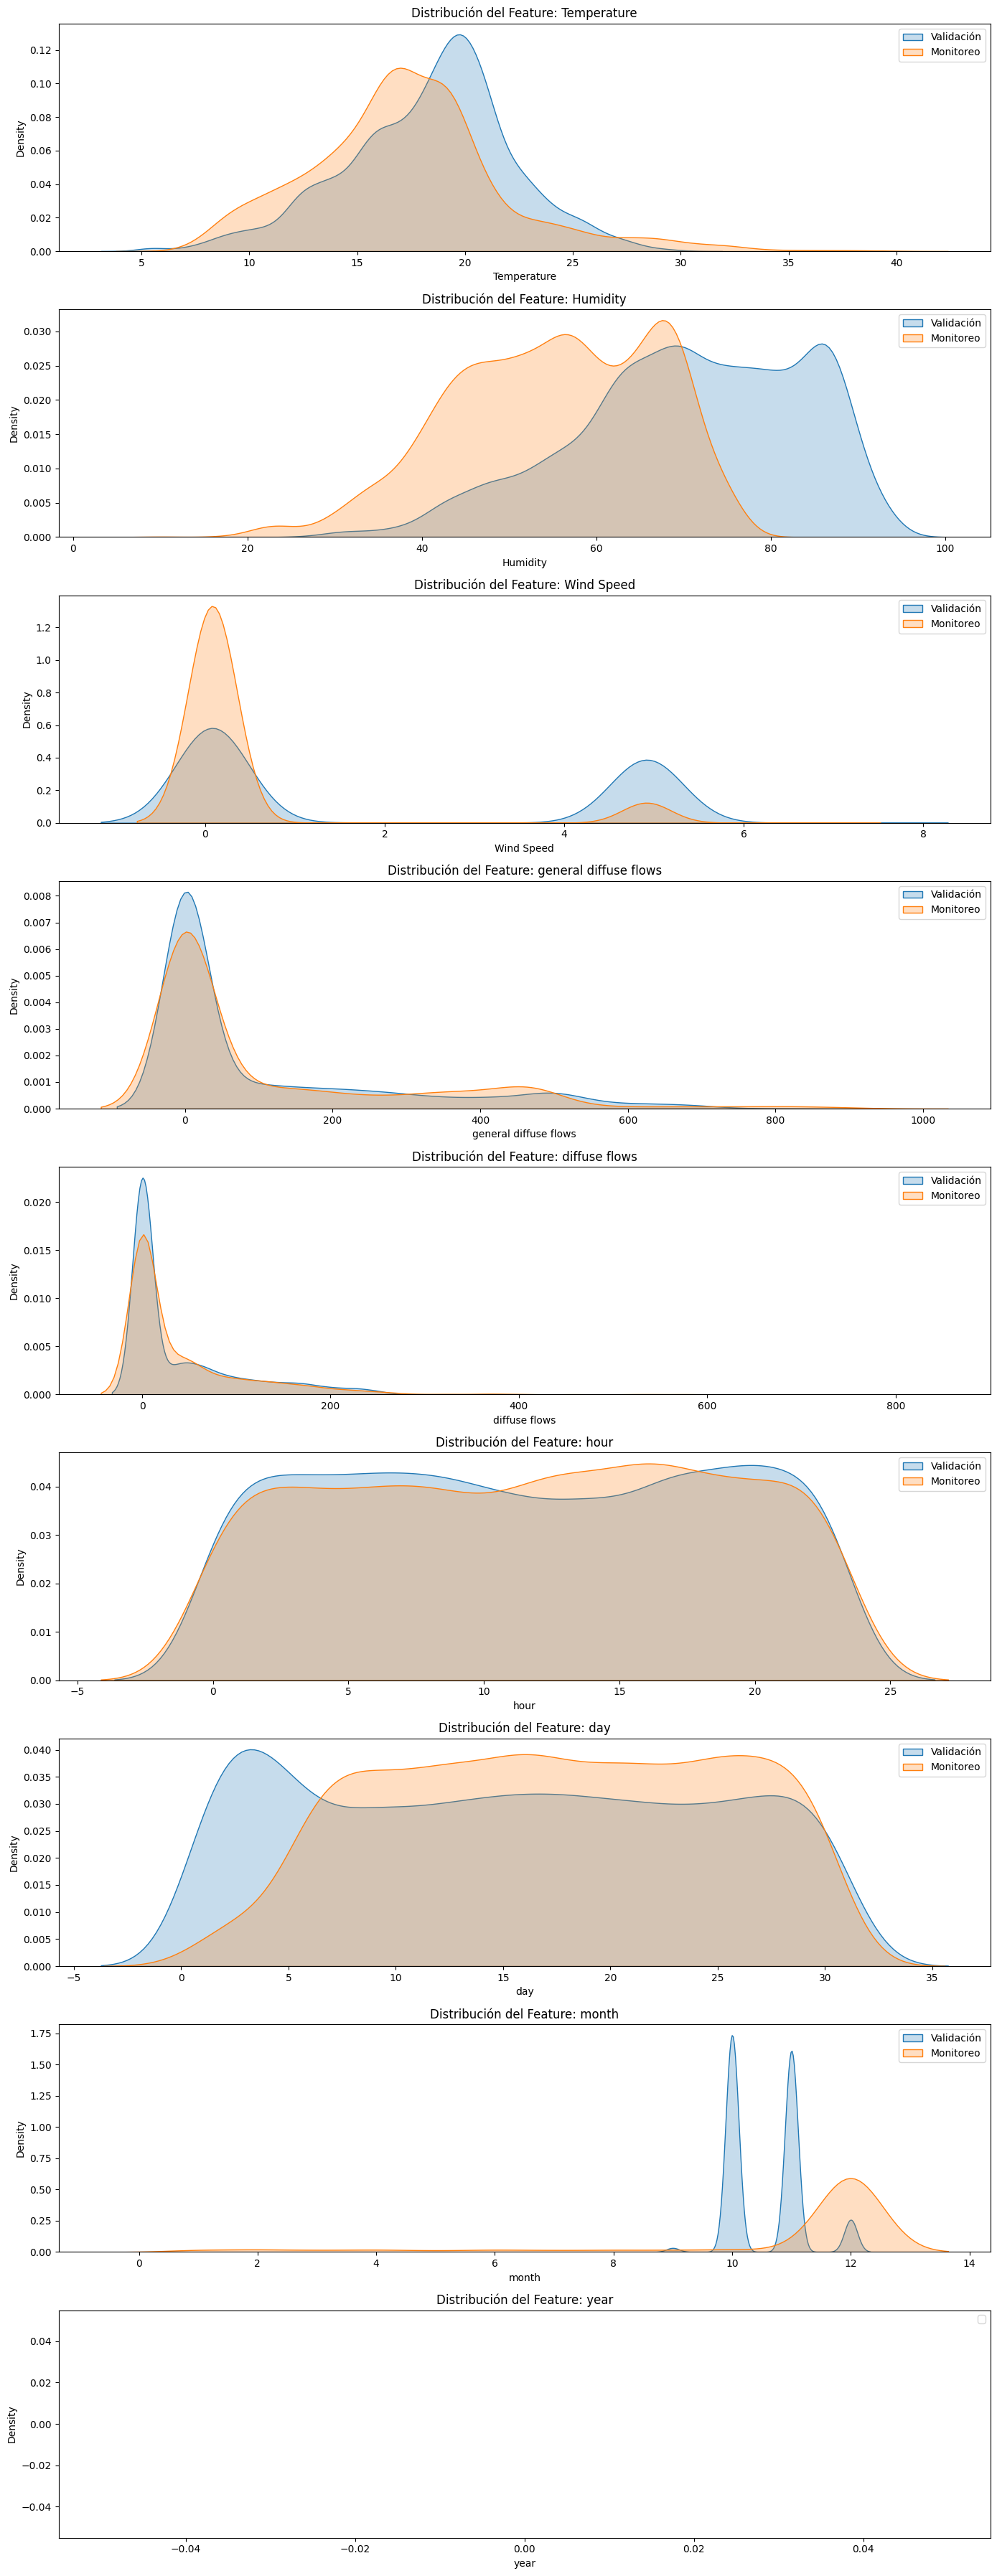

In [12]:
# GRAFICOS

plot_feature_shift(X_val, X_mon_drift)


=== MÉTRICAS BASE ===
           MAE         RMSE        R2
0  2950.906359  3630.400011  0.450712

=== MÉTRICAS CON DRIFT ===
           MAE         RMSE        R2
0  3705.024708  4296.640446  0.392158

=== COMPARACIÓN ===
  Métrica   Validación  Monitoreo (Drift)  Cambio Relativo
0     MAE  2950.906359        3705.024708         0.255555
1    RMSE  3630.400011        4296.640446         0.183517
2      R2     0.450712           0.392158        -0.129915


/tmp/ipython-input-321685441.py:7: RuntimeWarning: divide by zero encountered in divide
  psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
/tmp/ipython-input-321685441.py:7: RuntimeWarning: divide by zero encountered in log
  psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
/tmp/ipython-input-321685441.py:7: RuntimeWarning: invalid value encountered in divide
  psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))



=== DETECCIÓN ESTADÍSTICA ===
                 Feature       PSI     KS p-value
0            Temperature  1.971241   2.235892e-68
1               Humidity  0.059725  6.057245e-321
2             Wind Speed  3.012661  8.597118e-218
3  general diffuse flows  0.087526   1.611679e-07
4          diffuse flows       inf   1.919677e-41
5                   hour  0.007804   9.888269e-02
6                    day  0.233324   3.685344e-52
7                  month       inf   0.000000e+00
8                   year       NaN   1.000000e+00

🚨 ALERTA DE DATA DRIFT 🚨
- Degradación significativa del modelo.
- PSI indica drift fuerte.
- KS detecta cambio estadístico significativo.


/tmp/ipython-input-321685441.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_val[feat], label="Validación", fill=True)
/tmp/ipython-input-321685441.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_mon[feat], label="Monitoreo", fill=True)
/tmp/ipython-input-321685441.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


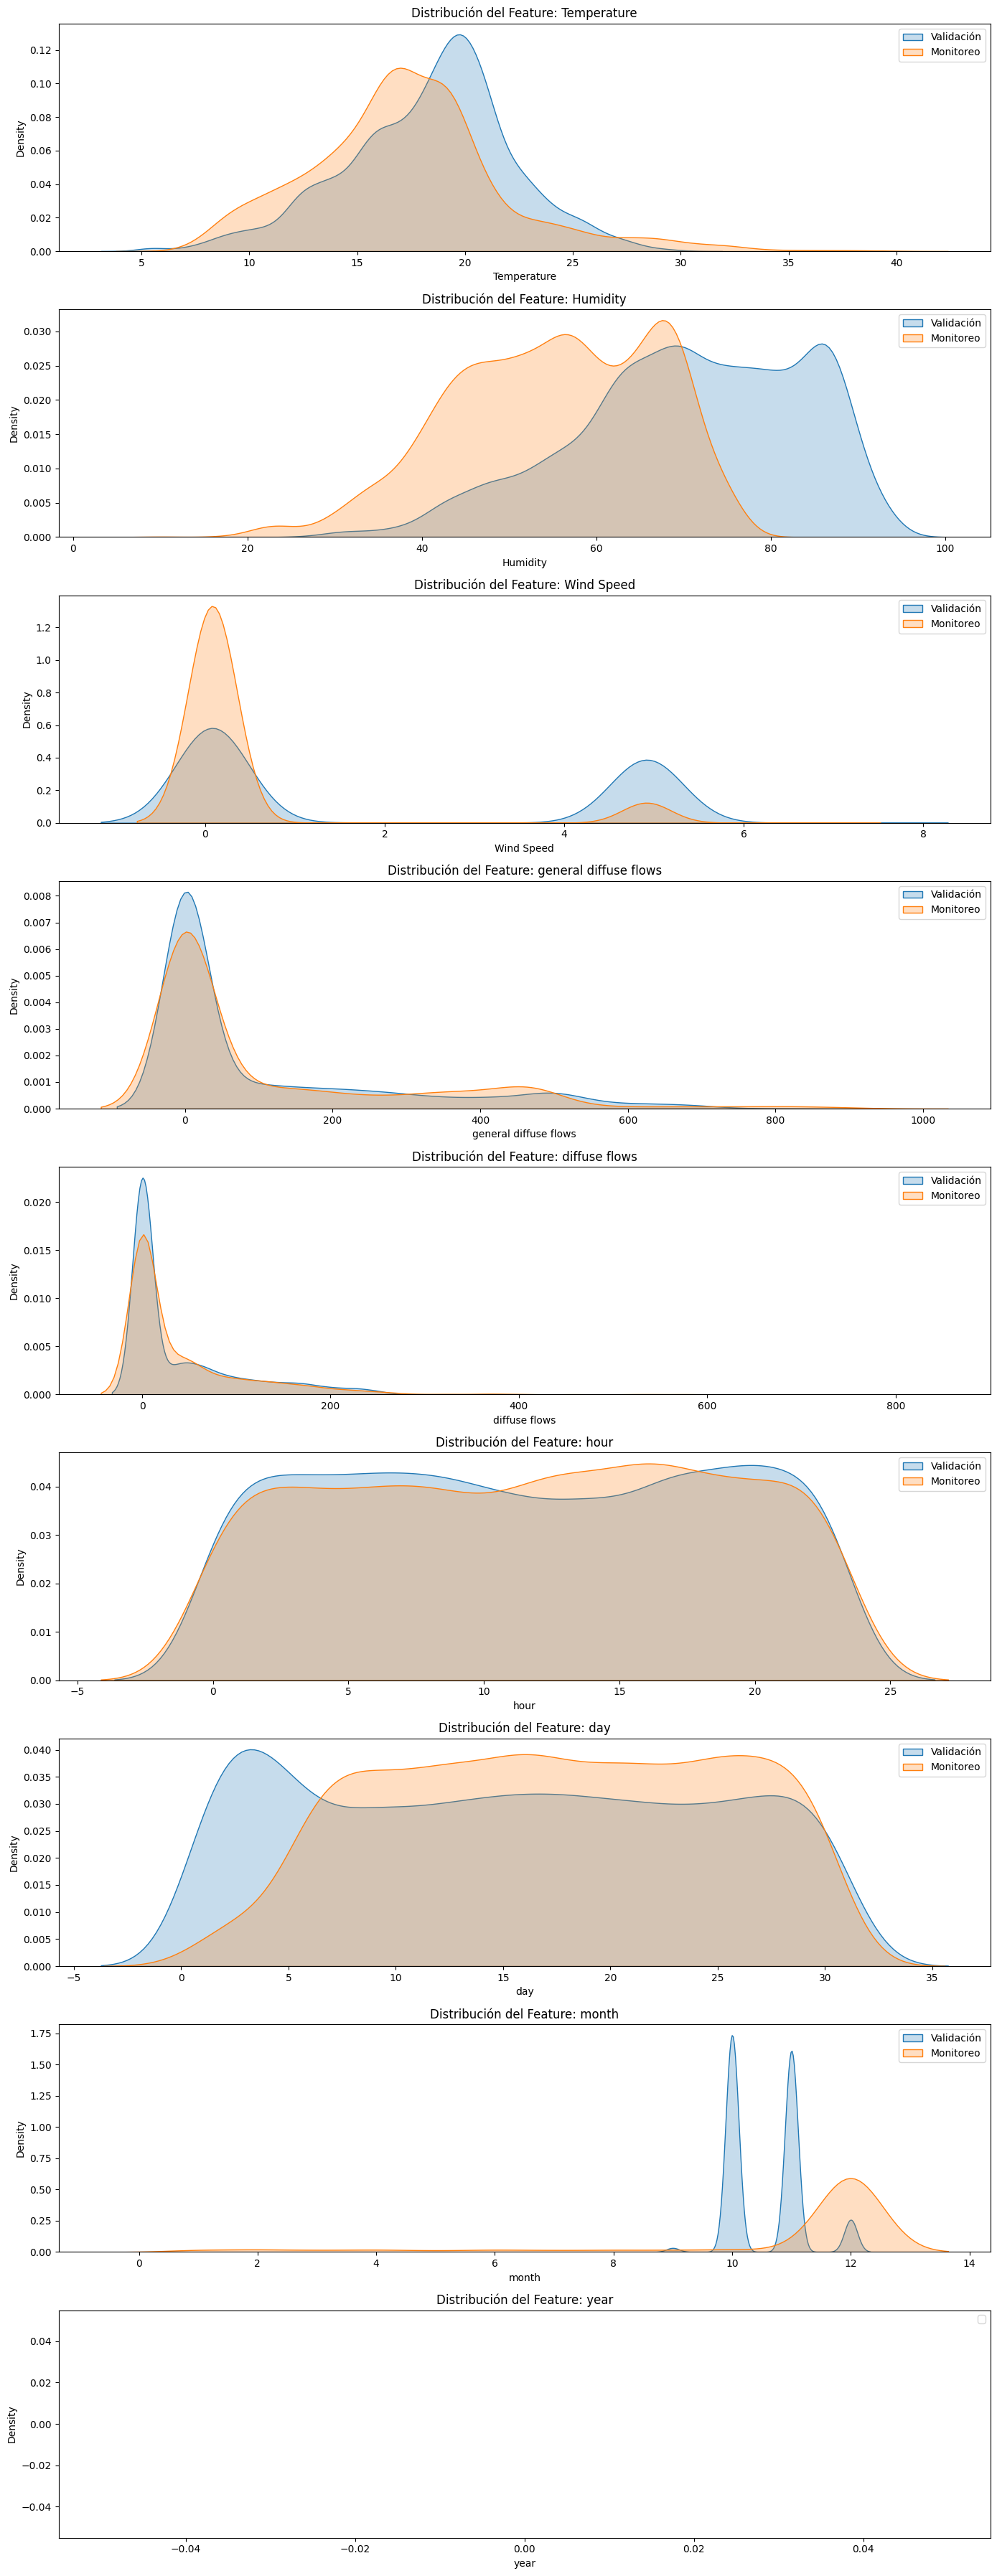

In [17]:
#Versión con Random Forest
# ENTRENAR RANDOM FOREST

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# MÉTRICAS BASE (VALIDACIÓN)

pred_val = model.predict(X_val)
baseline_metrics = {
    "MAE": mean_absolute_error(y_val, pred_val),
    "RMSE": mean_squared_error(y_val, pred_val)**0.5,
    "R2": r2_score(y_val, pred_val)
}
print("\n=== MÉTRICAS BASE ===")
print(pd.DataFrame([baseline_metrics]))

# SIMULACIÓN REALISTA DE DATA DRIFT

def simulate_real_drift(X):
    drift = X.copy()

    # Drift climático
    if "Temperature" in drift.columns:
        drift["Temperature"] += 3
    if "Humidity" in drift.columns:
        drift["Humidity"] *= 0.8

    # Drift sensores
    if "WindSpeed" in drift.columns:
        drift["WindSpeed"] *= 0.75
    if "DiffuseFlows" in drift.columns:
        mask_missing = np.random.rand(len(drift)) < 0.10
        drift.loc[mask_missing, "DiffuseFlows"] = np.nan

    # Completar valores faltantes con media
    drift = drift.fillna(drift.mean())
    return drift

X_mon_drift = simulate_real_drift(X_mon)

#  MÉTRICAS POST-DRIFT

pred_mon = model.predict(X_mon_drift)
drift_metrics = {
    "MAE": mean_absolute_error(y_mon, pred_mon),
    "RMSE": mean_squared_error(y_mon, pred_mon)**0.5,
    "R2": r2_score(y_mon, pred_mon)
}
print("\n=== MÉTRICAS CON DRIFT ===")
print(pd.DataFrame([drift_metrics]))

# COMPARACIÓN DE MÉTRICAS

comparison = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R2"],
    "Validación": list(baseline_metrics.values()),
    "Monitoreo (Drift)": list(drift_metrics.values())
})
comparison["Cambio Relativo"] = (
    comparison["Monitoreo (Drift)"] - comparison["Validación"]
) / comparison["Validación"]
print("\n=== COMPARACIÓN ===")
print(comparison)

# DETECCIÓN ESTADÍSTICA (PSI + KS)

psi_scores = []
ks_scores = []
for feat in feature_cols:
    psi_scores.append(calculate_psi(X_val[feat], X_mon_drift[feat]))
    ks_scores.append(ks_2samp(X_val[feat], X_mon_drift[feat]).pvalue)

stats_df = pd.DataFrame({
    "Feature": feature_cols,
    "PSI": psi_scores,
    "KS p-value": ks_scores
})
print("\n=== DETECCIÓN ESTADÍSTICA ===")
print(stats_df)

# ALERTAS DE DRIFT

METRIC_THRESHOLD = 0.20
PSI_THRESHOLD = 0.2
KS_THRESHOLD = 0.05

metric_alert = any(abs(comparison["Cambio Relativo"]) > METRIC_THRESHOLD)
psi_alert = any(stats_df["PSI"] > PSI_THRESHOLD)
ks_alert = any(stats_df["KS p-value"] < KS_THRESHOLD)

if metric_alert or psi_alert or ks_alert:
    print("\n🚨 ALERTA DE DATA DRIFT 🚨")
    if metric_alert: print("- Degradación significativa del modelo.")
    if psi_alert: print("- PSI indica drift fuerte.")
    if ks_alert: print("- KS detecta cambio estadístico significativo.")
else:
    print("\n✔ No se detectó drift significativo.")

# GRAFICOS

plot_feature_shift(X_val, X_mon_drift)